# Wind Speed Regression — Model Training and Comparison

This notebook trains and compares three regression models:

1. Multiple Linear Regression
2. Gradient Boosting Regressor
3. HistGradientBoostingRegressor

### Input (X)
- `surface_pressure_mean`
- `surface_pressure_max`
- `surface_pressure_min`
- `pressure_change`
- `wind_direction_10m_dominant`

### Output (y)
- `wind_speed_10m_max` in km/h

The dataset is split chronologically:
- **2021–2025:** training
- **2026:** testing

Evaluation metrics:
- MAE
- RMSE
- R²


In [1]:
from pathlib import Path
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Resolve project directory.
ROOT = Path.cwd()
if ROOT.name.lower() != "wind":
    if (ROOT / "Wind").exists():
        ROOT = ROOT / "Wind"

DATA_FILE = ROOT / "dataset" / "wind_preprocessed.csv"
MODEL_DIR = ROOT / "trained_models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

FEATURES = [
    "surface_pressure_mean",
    "surface_pressure_max",
    "surface_pressure_min",
    "pressure_change",
    "wind_direction_10m_dominant",
]

TARGET = "wind_speed_10m_max"

print("Project root:", ROOT)
print("Dataset:", DATA_FILE)


Project root: c:\Users\IAN\Desktop\SEM (SWIN)\SEM 2\COS30049-Computing Technology Innovation Project\Assignments\Dev\Wind
Dataset: c:\Users\IAN\Desktop\SEM (SWIN)\SEM 2\COS30049-Computing Technology Innovation Project\Assignments\Dev\Wind\dataset\wind_preprocessed.csv


## 1. Load the preprocessed Wind dataset


In [2]:
df = pd.read_csv(DATA_FILE)
df["date"] = pd.to_datetime(df["date"], errors="coerce")

required = ["date"] + FEATURES + [TARGET]
missing = [c for c in required if c not in df.columns]

if missing:
    raise KeyError(f"Missing required columns: {missing}")

for c in FEATURES + [TARGET]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=required).copy()
df = df.sort_values("date").reset_index(drop=True)

print("Rows:", f"{len(df):,}")
print("Date range:", df["date"].min(), "to", df["date"].max())
display(df.head())


Rows: 458,432
Date range: 2021-01-02 00:00:00 to 2026-01-31 00:00:00


,date,prefecture,location_id,town,surface_pressure_mean,surface_pressure_max,surface_pressure_min,pressure_change,wind_direction_10m_dominant,wind_speed_10m_max
0,2021-01-02,Aichi,0,Nagoya,1019.1,1022.0,1016.3,1.5,309,25.9
1,2021-01-02,Oita,0,Oita,1024.2,1026.4,1023.0,0.7,298,18.6
2,2021-01-02,Oita,1,Nakatsu,1024.5,1027.0,1023.1,0.6,264,18.1
3,2021-01-02,Oita,2,Saeki,1024.4,1026.6,1023.0,0.6,303,14.7
4,2021-01-02,Oita,3,Hita,1014.4,1016.6,1012.9,0.7,264,12.1


## 2. Basic Wind Speed Distribution


count    458432.000000
mean         18.671161
std           8.421484
min           2.300000
25%          12.500000
50%          17.000000
75%          23.100000
max         119.300000
Name: wind_speed_10m_max, dtype: float64


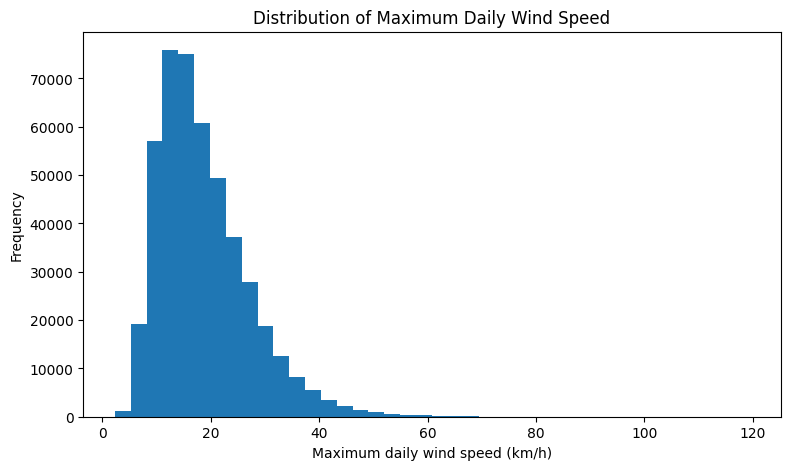

In [3]:
print(df[TARGET].describe())

plt.figure(figsize=(9, 5))
plt.hist(df[TARGET], bins=40)
plt.xlabel("Maximum daily wind speed (km/h)")
plt.ylabel("Frequency")
plt.title("Distribution of Maximum Daily Wind Speed")
plt.show()


## 3. Chronological Train/Test Split


In [4]:
train = df[df["date"].dt.year <= 2025].copy()
test = df[df["date"].dt.year == 2026].copy()

if train.empty:
    raise ValueError("Training set is empty.")
if test.empty:
    raise ValueError("2026 testing set is empty.")

X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

print("Training rows:", f"{len(train):,}")
print("Testing rows :", f"{len(test):,}")
print("Training:", train["date"].min(), "to", train["date"].max())
print("Testing :", test["date"].min(), "to", test["date"].max())

train.to_csv(MODEL_DIR / "training.csv", index=False)
test.to_csv(MODEL_DIR / "testing.csv", index=False)

print("Saved training.csv and testing.csv")


Training rows: 450,775
Testing rows : 7,657
Training: 2021-01-02 00:00:00 to 2025-12-31 00:00:00
Testing : 2026-01-01 00:00:00 to 2026-01-31 00:00:00
Saved training.csv and testing.csv


## 4. Define Models

`HistGradientBoostingRegressor` is included as the more computationally efficient
tree-based boosting model for larger datasets.

Random Forest and MARS are not used in this experiment.


In [5]:
models = {
    "Multiple Linear Regression": LinearRegression(),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "HistGradientBoosting": HistGradientBoostingRegressor(
        learning_rate=0.1,
        max_iter=200,
        max_leaf_nodes=31,
        random_state=42
    ),
}

MODEL_FILES = {
    "Multiple Linear Regression": "multiple_linear_regression.joblib",
    "Gradient Boosting": "gradient_boosting.joblib",
    "HistGradientBoosting": "hist_gradient_boosting.joblib",
}

models


{'Multiple Linear Regression': LinearRegression(),
 'Gradient Boosting': GradientBoostingRegressor(learning_rate=0.05, n_estimators=200, random_state=42),
 'HistGradientBoosting': HistGradientBoostingRegressor(max_iter=200, random_state=42)}

## 5. Train, Predict, Evaluate and Save


In [6]:
results = []
predictions = {}

for name, model in models.items():
    print("\n" + "=" * 70)
    print("Training:", name)
    print("=" * 70)

    start = time.time()

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    elapsed = time.time() - start

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    results.append({
        "Model": name,
        "MAE (km/h)": mae,
        "RMSE (km/h)": rmse,
        "R²": r2,
        "Training time (s)": elapsed,
    })

    predictions[name] = pred

    path = MODEL_DIR / MODEL_FILES[name]
    joblib.dump(model, path)

    print(f"MAE : {mae:.4f} km/h")
    print(f"RMSE: {rmse:.4f} km/h")
    print(f"R²  : {r2:.4f}")
    print(f"Time: {elapsed:.2f} seconds")
    print("Saved:", path)

results_df = pd.DataFrame(results).sort_values("RMSE (km/h)").reset_index(drop=True)
results_df.to_csv(MODEL_DIR / "model_results.csv", index=False)

display(results_df)



Training: Multiple Linear Regression
MAE : 6.4894 km/h
RMSE: 8.6419 km/h
R²  : 0.0665
Time: 0.07 seconds
Saved: c:\Users\IAN\Desktop\SEM (SWIN)\SEM 2\COS30049-Computing Technology Innovation Project\Assignments\Dev\Wind\trained_models\multiple_linear_regression.joblib

Training: Gradient Boosting
MAE : 6.3127 km/h
RMSE: 8.4386 km/h
R²  : 0.1099
Time: 95.10 seconds
Saved: c:\Users\IAN\Desktop\SEM (SWIN)\SEM 2\COS30049-Computing Technology Innovation Project\Assignments\Dev\Wind\trained_models\gradient_boosting.joblib

Training: HistGradientBoosting
MAE : 6.2465 km/h
RMSE: 8.3204 km/h
R²  : 0.1346
Time: 3.98 seconds
Saved: c:\Users\IAN\Desktop\SEM (SWIN)\SEM 2\COS30049-Computing Technology Innovation Project\Assignments\Dev\Wind\trained_models\hist_gradient_boosting.joblib


,Model,MAE (km/h),RMSE (km/h),R²,Training time (s)
0,HistGradientBoosting,6.246537,8.320368,0.134639,3.980364
1,Gradient Boosting,6.312702,8.438605,0.109869,95.097015
2,Multiple Linear Regression,6.489352,8.641873,0.066470,0.068327


## 6. Actual vs Predicted


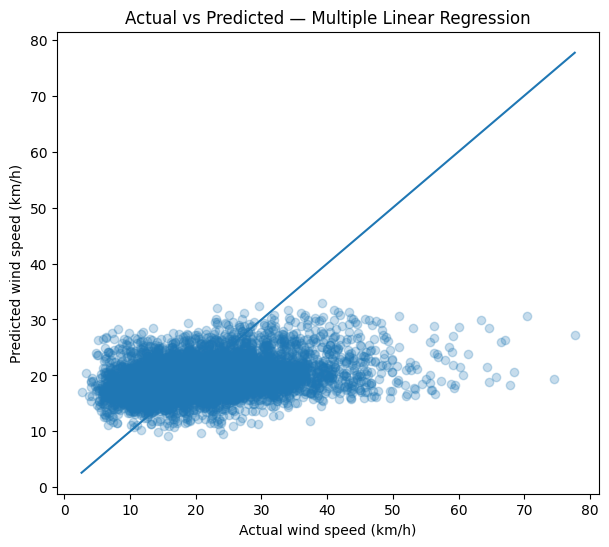

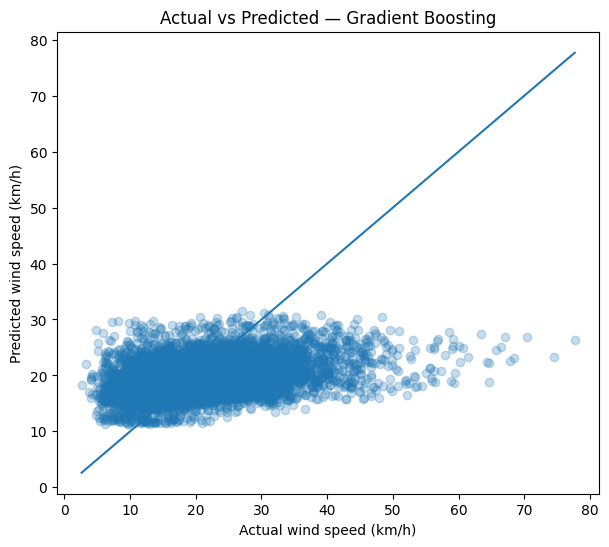

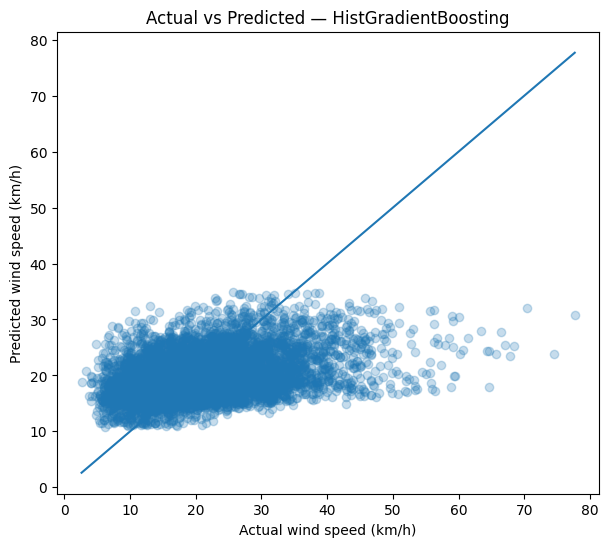

In [7]:
for name, pred in predictions.items():
    plt.figure(figsize=(7, 6))
    plt.scatter(y_test, pred, alpha=0.25)

    low = min(y_test.min(), pred.min())
    high = max(y_test.max(), pred.max())
    plt.plot([low, high], [low, high])

    plt.xlabel("Actual wind speed (km/h)")
    plt.ylabel("Predicted wind speed (km/h)")
    plt.title(f"Actual vs Predicted — {name}")
    plt.show()


## 7. Compare Errors


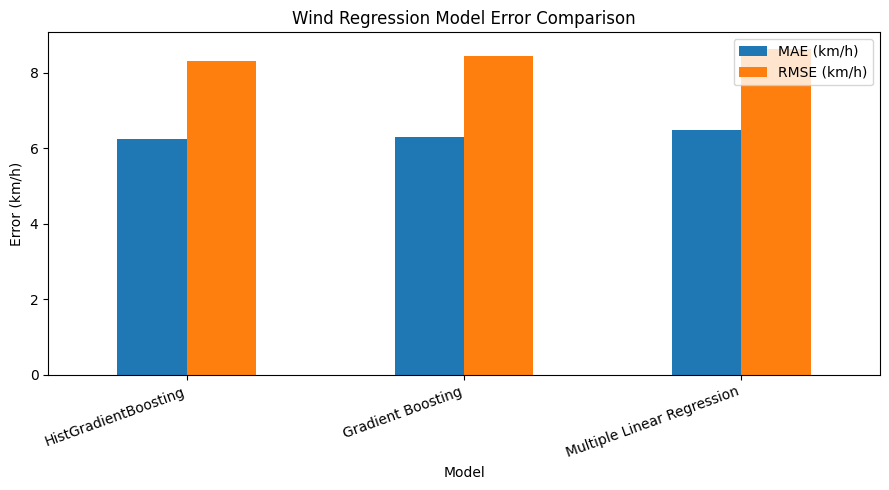

In [8]:
plot_df = results_df.set_index("Model")

plt.figure(figsize=(9, 5))
plot_df[["MAE (km/h)", "RMSE (km/h)"]].plot(kind="bar", ax=plt.gca())
plt.ylabel("Error (km/h)")
plt.title("Wind Regression Model Error Comparison")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## 8. Multiple Linear Regression Coefficients


In [9]:
mlr = models["Multiple Linear Regression"]

coef_df = pd.DataFrame({
    "Feature": FEATURES,
    "Coefficient": mlr.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

display(coef_df)


,Feature,Coefficient
2,surface_pressure_min,-0.998823
0,surface_pressure_mean,0.557389
1,surface_pressure_max,0.496413
3,pressure_change,0.031429
4,wind_direction_10m_dominant,0.009622


## 9. Final Model Ranking

For **MAE** and **RMSE**, lower is better.

For **R²**, higher is better and values closer to 1 indicate that the model explains
more of the variation in maximum wind speed.

Do not select the final model from training time alone. Compare predictive performance
and computational cost together.


In [10]:
display(
    results_df[
        ["Model", "MAE (km/h)", "RMSE (km/h)", "R²", "Training time (s)"]
    ]
)

best = results_df.iloc[0]
print("Lowest RMSE model:", best["Model"])
print(f'RMSE: {best["RMSE (km/h)"]:.4f} km/h')
print(f'MAE : {best["MAE (km/h)"]:.4f} km/h')
print(f'R²  : {best["R²"]:.4f}')


,Model,MAE (km/h),RMSE (km/h),R²,Training time (s)
0,HistGradientBoosting,6.246537,8.320368,0.134639,3.980364
1,Gradient Boosting,6.312702,8.438605,0.109869,95.097015
2,Multiple Linear Regression,6.489352,8.641873,0.066470,0.068327


Lowest RMSE model: HistGradientBoosting
RMSE: 8.3204 km/h
MAE : 6.2465 km/h
R²  : 0.1346
